## Script fusion dataset

In [47]:
import pandas as pd

print("Chargement des données...")
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
products = pd.read_csv('./datasets/products.csv')
orders = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv') 

print("Fusion en cours...")
products_enriched = products.merge(aisles, on='aisle_id', how='left')
products_enriched = products_enriched.merge(departments, on='department_id', how='left')

orders_details = order_products.merge(orders, on='order_id', how='left')

df_master = orders_details.merge(products_enriched, on='product_id', how='left')

print("Fusion terminée !")
display(df_master.head())
print(f"Dimensions du dataset final : {df_master.shape}")

Chargement des données...
Fusion en cours...
Fusion terminée !


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Organic Egg Whites,86.0,16.0,eggs,dairy eggs
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,NaN,Garlic Powder,104.0,13.0,spices seasonings,pantry
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Coconut Butter,19.0,13.0,oils vinegars,pantry
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,NaN,Natural Sweetener,17.0,13.0,baking ingredients,pantry


Dimensions du dataset final : (13692886, 15)


## Peak Days

Nombre de commandes par jour :
order_dow
0.0       9608
1.0       5213
2.0       3189
3.0       2280
4.0       2345
5.0       4062
6.0      12997
7.0      38687
8.0      75137
9.0     109220
10.0    122020
11.0    119964
12.0    114884
13.0    117439
14.0    119428
15.0    119754
16.0    115372
17.0     96566
18.0     77587
19.0     59275
20.0     43848
21.0     32721
22.0     26100
23.0     16725
Name: count, dtype: int64


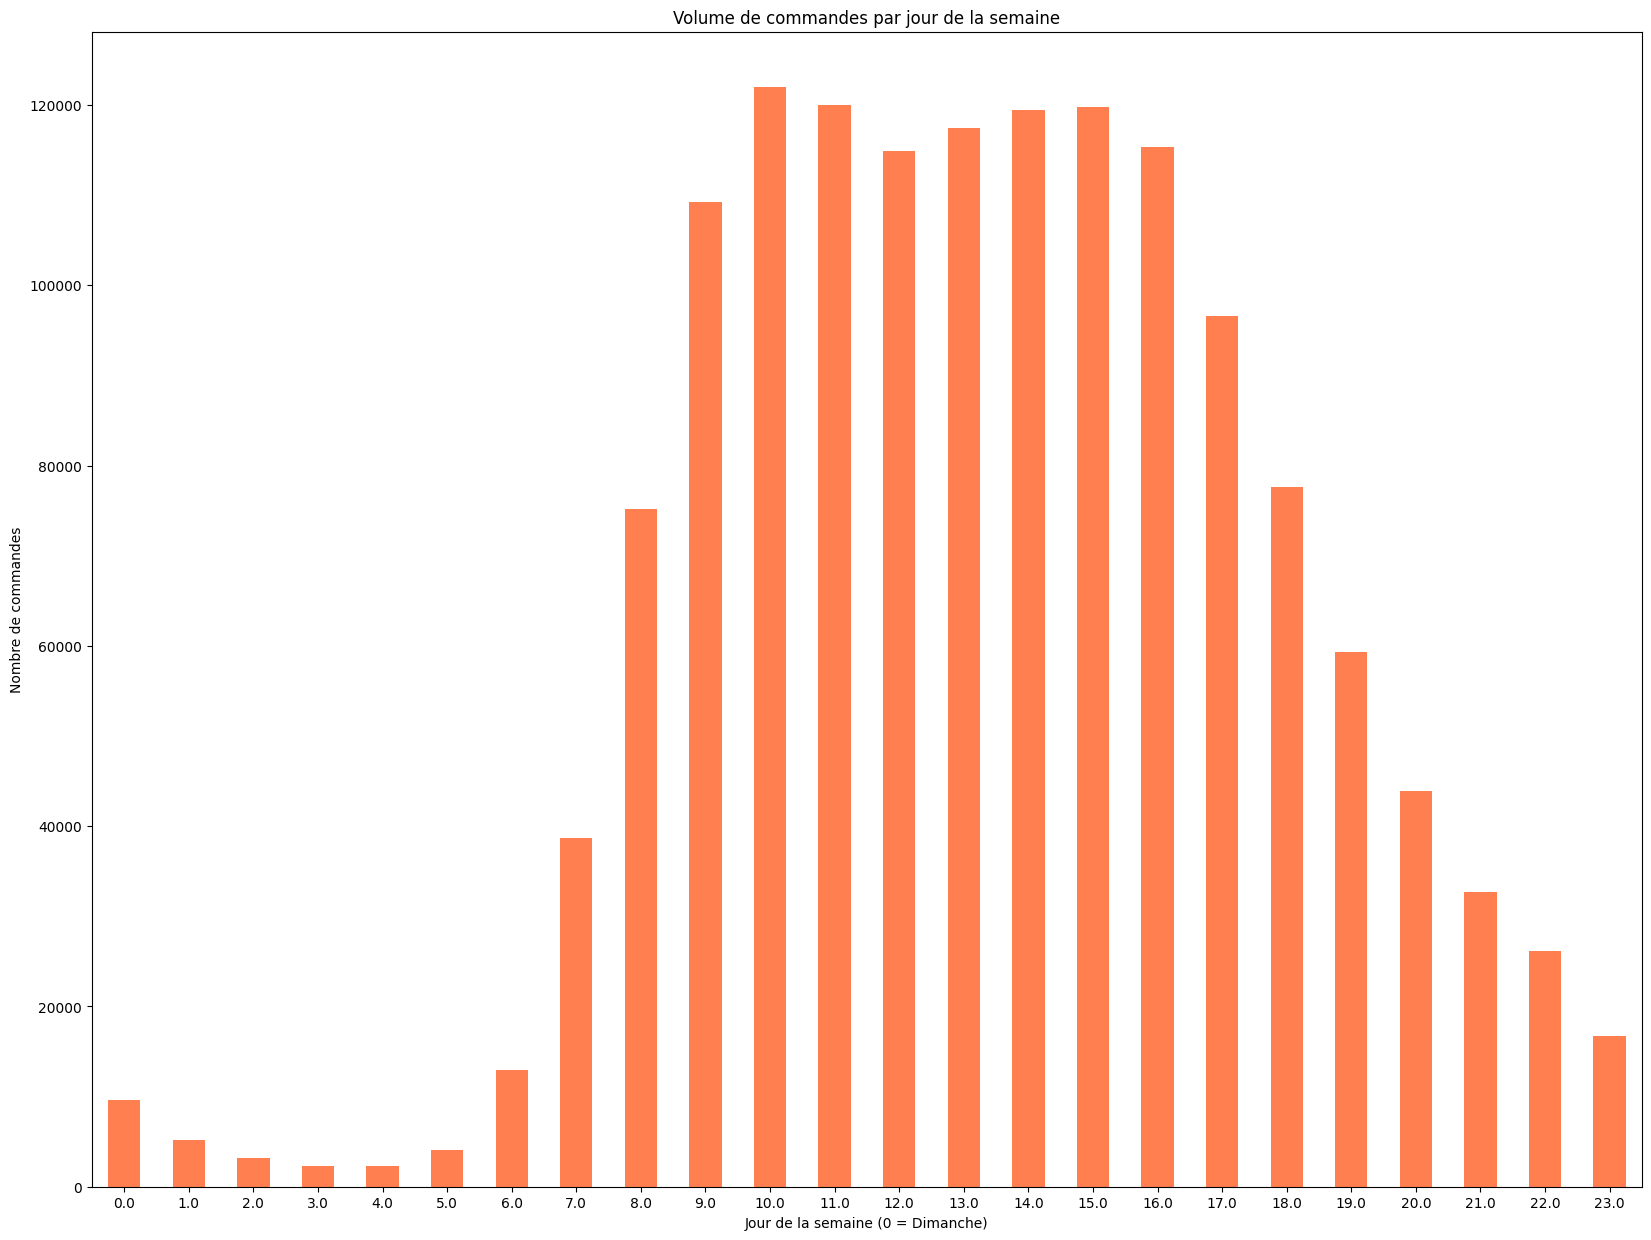

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv('./datasets/orders.csv')

peak_days = orders['order_dow'].value_counts().sort_index()

print("Nombre de commandes par jour :")
print(peak_days)

peak_days.plot(kind='bar', color='coral', figsize=(20, 15))
plt.title('Volume de commandes par jour de la semaine')
plt.xlabel('Jour de la semaine (0 = Dimanche)')
plt.ylabel('Nombre de commandes')
plt.xticks(rotation=0)
plt.show()

----------------------------------------------------------

## Product to buy before all customers buy it

## Chargement des datas

In [49]:
import pandas as pd
print("chargement des données")
order = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv')

chargement des données


## On joins les produits commandés avec le jour de la commande (order_dow)

In [50]:
print("Analyse des Ventes par jour")

Analyse des Ventes par jour


## On prend que les collones utiles de 'orders' pour éco la mémoire RAM

In [51]:
df_sales = order_products[['order_id', 'product_id']].merge(orders[['order_id', 'order_dow']],
on='order_id', how='left')

## Calculer le nombre total de ventes par produit

In [52]:
##dd = (df_sales[["products_id", "products_name"]].head())
total_sales = df_sales.groupby('product_id').size().reset_index(name='total sales')
display(total_sales)

,product_id,total sales
0,1.0,773
1,2.0,37
2,3.0,94
3,4.0,149
4,5.0,6
...,...,...
49062,49684.0,5
49063,49685.0,19
49064,49686.0,49
49065,49687.0,4


## Calculer le nombre total de ventes spécifiquement le week-end

In [53]:
weekend_sales = df_sales[df_sales['order_dow'].isin([0.0, 1.0])]
weekend_sales_count = weekend_sales.groupby('product_id').size().reset_index(name='weekend_sales')
display(weekend_sales)
display(weekend_sales_count)

,order_id,product_id,order_dow
187,47,16797.0,0.0
188,47,39275.0,0.0
189,47,43352.0,0.0
190,47,46041.0,0.0
191,47,29223.0,0.0
...,...,...,...
13692263,2999940,644.0,1.0
13692264,2999940,12162.0,1.0
13692265,2999940,38861.0,1.0
13692266,2999940,19131.0,1.0


,product_id,weekend_sales
0,1.0,9
1,3.0,2
2,4.0,2
3,7.0,1
4,10.0,13
...,...,...
19166,49680.0,5
19167,49682.0,2
19168,49683.0,473
19169,49685.0,1


## Fusionner pour comparer le total et le Week-end

In [54]:
target_df = total_sales.merge(weekend_sales_count, on='product_id', how='left')
display(target_df)

,product_id,total sales,weekend_sales
0,1.0,773,9.0
1,2.0,37,NaN
2,3.0,94,2.0
3,4.0,149,2.0
4,5.0,6,NaN
...,...,...,...
49062,49684.0,5,NaN
49063,49685.0,19,1.0
49064,49686.0,49,1.0
49065,49687.0,4,NaN


## Si un produit n'a jamais été vendu le week-end, on remplace le vide (NaN) par 0

In [55]:
target_df['weekend_sales'] = target_df['weekend_sales'].fillna(0)

## Calculer le pourcentage des ventes du weekend (ratio)

In [56]:
target_df['weekend_ratio'] = (target_df['weekend_sales'] / target_df['total sales']).fillna(0)

## On crée la variable cible donc target
## On prend un seuil de 40% -> (0.40)

In [57]:
seuil = 0.40
target_df['is_weekend_bestseller'] = (target_df['weekend_ratio'] >= seuil).astype(int)


## Afficher les 10 premiers résultats

In [58]:
print("\n Aperçu des  produits")
display(target_df.head(10))


 Aperçu des  produits


,product_id,total sales,weekend_sales,weekend_ratio,is_weekend_bestseller
0,1.0,773,9.0,0.011643,0
1,2.0,37,0.0,0.000000,0
2,3.0,94,2.0,0.021277,0
3,4.0,149,2.0,0.013423,0
4,5.0,6,0.0,0.000000,0
5,6.0,3,0.0,0.000000,0
6,7.0,16,1.0,0.062500,0
7,8.0,69,0.0,0.000000,0
8,9.0,68,0.0,0.000000,0
9,10.0,1090,13.0,0.011927,0


## Aficher la répartition des classes (Produits 1 vs 0)

In [59]:
print("\n Répartition de la cible" )
print(target_df['is_weekend_bestseller'].value_counts(normalize=True) * 100)


 Répartition de la cible
is_weekend_bestseller
0    99.828806
1     0.171194
Name: proportion, dtype: float64


------------------------------------------------------------------

## Which products have the highest probability of being reordered?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
products = pd.read_csv('./datasets/products.csv')
orders = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv') 

print(f"order_products: {order_products.shape[0]:,} lignes")
print(f"orders: {orders.shape[0]:,} lignes")
print(f"products: {products.shape[0]:,} lignes")

ça charge...
order_products: 13,692,886 lignes
orders: 1,444,444 lignes
products: 49,688 lignes


In [ ]:
products_stats = (
    order_products.groupby('product_id').agg(
        total_orders = ('order_id', 'count'),
        reorder_count = ('reordered', 'sum'),
        avg_cart_position = ('add_to_cart_order', 'mean'),
        min_cart_position = ('add_to_cart_order', 'min'),
    )
    .reset_index()
)
products_stats['reorder_rate'] = products_stats['reorder_count']
products_stats['total_orders']

median_rate = products_stats['reorder_rate'].median()
products_stats['high_reorder'] = (products_stats['reorder_rate'] >= median_rate).astype(int)

user_counts = (
    order_products
    .merge(orders[['order_id', 'user_id']], on='order_id')
    .groupby('product_id')['user_id']
    .nunique()
    .reset_index(name='unique_users')
)
products_stats = products_stats.merge(user_counts, on='product_id', how='left')
#on rattache aisle et département
product_full = (
    products
.merge(aisles,on='aisle_id')
.merge(departments,on='department_id')
.merge(products_stats,on='product_id', how='inner')
  )
#flag products bio
product_full['is_organic'] = product_full['product_name'].str.lower().str.contains('organic').astype(int)
print("features construites -->")
print(product_full[['product_name', 'department', 'total_orders', 'reorder_rate',
                 'avg_cart_position', 'unique_users', 'is_organic', 'high_reorder']].head())
print(f"\nDataset produits : {product_full.shape[0]:,} produits")
print(f"Médiane du taux de réachat (seuil) : {median_rate:.3f}")
print(f"Répartition de la cible :\n{product_full['high_reorder'].value_counts(normalize=True).mul(100).round(1).to_string()}")


features construites -->
                                        product_name department  total_orders  \
0                         Chocolate Sandwich Cookies     snacks           773   
1                                   All-Seasons Salt     pantry            37   
2               Robust Golden Unsweetened Oolong Tea  beverages            94   
3  Smart Ones Classic Favorites Mini Rigatoni Wit...     frozen           149   
4                          Green Chile Anytime Sauce     pantry             6   

   reorder_rate  avg_cart_position  unique_users  is_organic  high_reorder  
0         485.0           6.018111           399           0             1  
1           7.0          11.162162            32           0             0  
2          66.0           7.382979            45           0             1  
3          66.0           9.389262           113           0             1  
4           2.0           9.000000             4           0             0  

Dataset produits : 49,067

In [ ]:
FEATURES = ['total_orders', 'avg_cart_position', 'min_cart_position',
            'unique_users', 'is_organic']

X = product_full[FEATURES]
y = product_full['high_reorder']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#Modele LogisticRegressions:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=500, random_state=42))
])
pipe_lr.fit(X_train, y_train)

#Modèle Random Forest:
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10,
                                   random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)

#Résultats:
for name, pipe in [("Logistic Regression", pipe_lr), ("Random Forest", pipe_rf)]:
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    print(f"\n{'='*50}")
    print(f"  {name}  —  AUC-ROC : {auc:.4f}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['Low reorder', 'High reorder']))


  Logistic Regression  —  AUC-ROC : 0.9639
              precision    recall  f1-score   support

 Low reorder       0.85      0.95      0.90      4903
High reorder       0.94      0.83      0.89      4911

    accuracy                           0.89      9814
   macro avg       0.90      0.89      0.89      9814
weighted avg       0.90      0.89      0.89      9814


  Random Forest  —  AUC-ROC : 0.9969
              precision    recall  f1-score   support

 Low reorder       0.97      0.97      0.97      4903
High reorder       0.97      0.97      0.97      4911

    accuracy                           0.97      9814
   macro avg       0.97      0.97      0.97      9814
weighted avg       0.97      0.97      0.97      9814



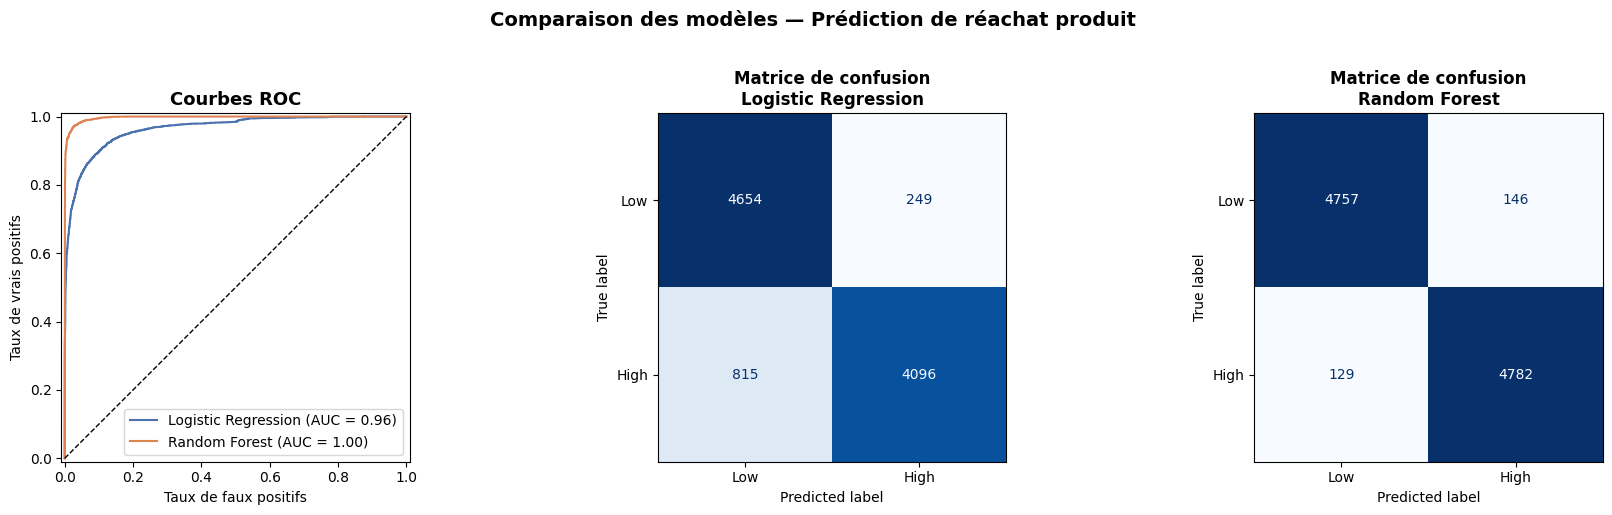

Les deux modèles affichent des performances similaires. Le Random Forest capte mieux les non-linéarités.


In [ ]:
# Visuel des deux modeles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#ROC Curves
for name, pipe, color in [
    ("Logistic Regression", pipe_lr, '#4C72B0'),
    ("Random Forest",       pipe_rf, '#DD8452')
]:
    RocCurveDisplay.from_estimator(pipe, X_test, y_test,
                                    name=name, ax=axes[0], color=color)
axes[0].set_title("Courbes ROC", fontsize=13, fontweight='bold')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")

#Matrice
for ax, (name, pipe) in zip(axes[1:], [
    ("Logistic Regression", pipe_lr),
    ("Random Forest",       pipe_rf)
]):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test,
        display_labels=['Low', 'High'],
        colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(f"Matrice de confusion\n{name}", fontsize=12, fontweight='bold')

plt.suptitle("Comparaison des modèles — Prédiction de réachat produit",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Les deux modèles sont similaires mais random Forest capte mieux les non-linéarités.")

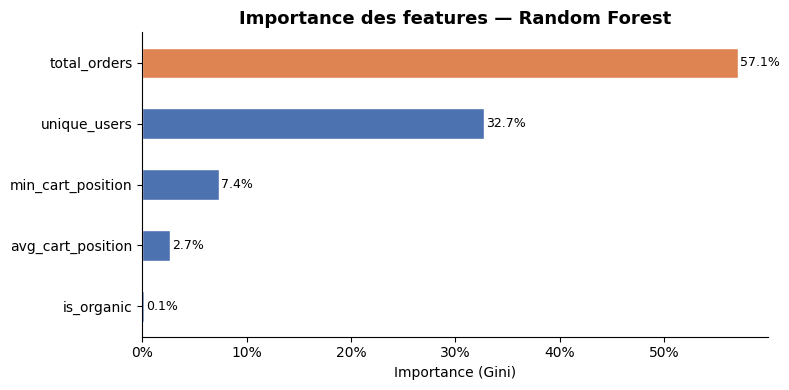

Le nombre total de commandes et le nombre d'utilisateurs uniques sont les signaux les plus prédictifs.


In [ ]:
#features Random Forest
importances = (
    pd.Series(pipe_rf['clf'].feature_importances_, index=FEATURES)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4C72B0' if v < importances.max() else '#DD8452' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title("features Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel()
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for patch, val in zip(ax.patches, importances):
    ax.text(val + 0.002, patch.get_y() + patch.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Le nombre total de commandes et le nombre d'utilisateurs uniques sont les signaux les plus prédictifs.")

In [ ]:
#Les 20 produits avec la plus haute probabilité de réachat
product_full['reorder_proba_rf'] = pipe_rf.predict_proba(product_full[FEATURES])[:, 1]
product_full['reorder_proba_lr'] = pipe_lr.predict_proba(product_full[FEATURES])[:, 1]

top20 = (
    product_full
    .sort_values('reorder_proba_rf', ascending=False)
    .drop_duplicates('product_name')
    .head(20)
    [['product_name', 'department', 'aisle', 'total_orders',
      'reorder_rate', 'reorder_proba_rf', 'is_organic']]
    .reset_index(drop=True)
)
top20.index += 1

print("Les 20 produits qui ont une probabilité de réachat (Random Forest)")
display(top20.style
        .format({'reorder_rate': '{:.1%}', 'reorder_proba_rf': '{:.1%}', 'total_orders': '{:,}'})
        .background_gradient(subset='reorder_proba_rf', cmap='Greens')
        .set_caption("Les 20 produits les plus susceptibles d'être recommandés"))


Top 20 produits — probabilité de réachat (Random Forest)


,product_name,department,aisle,total_orders,reorder_rate,reorder_proba_rf,is_organic
1,Organic 2% Chocolate Milk,dairy eggs,milk,"1,319",94900.0%,100.0%,1
2,Organic Variety Pack,beverages,juice nectars,"1,315",70300.0%,100.0%,1
3,Organic Low Fat Milk,dairy eggs,milk,"3,503",293300.0%,100.0%,1
4,Organic Coconut Water,beverages,water seltzer sparkling water,"2,277",170800.0%,100.0%,1
5,Bag of Organic Bananas,produce,fresh fruits,"160,615",13358600.0%,100.0%,1
6,"Milk, Organic, Vitamin D",dairy eggs,milk,"8,518",722300.0%,100.0%,1
7,Organic Virgin Coconut Oil,pantry,oils vinegars,510,18000.0%,100.0%,1
8,"Organic Milk Reduced Fat, 2% Milkfat",dairy eggs,milk,"5,344",453200.0%,100.0%,1
9,Frozen Organic Blueberries,produce,fresh fruits,"2,785",164800.0%,100.0%,1
10,Organic Reduced Fat Milk,dairy eggs,milk,"14,971",1271000.0%,100.0%,1


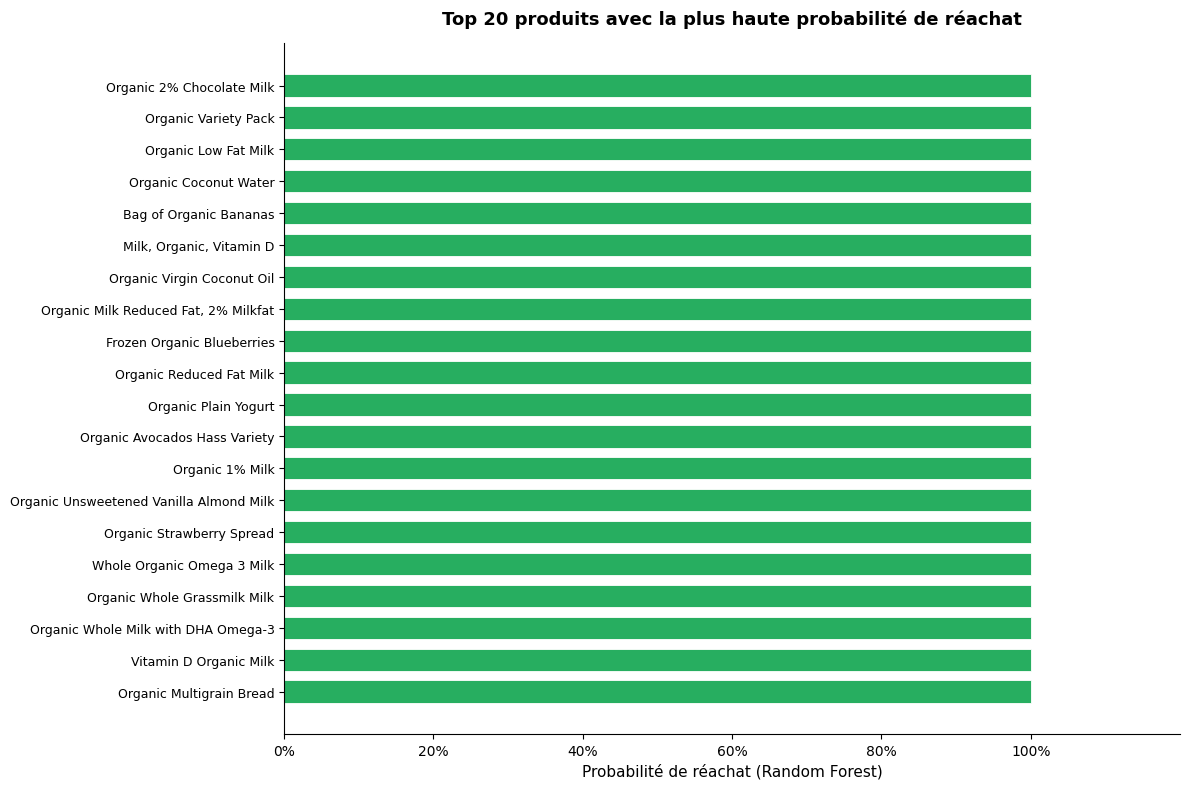

In [ ]:
#Graphique des 20 produits par probabilité de réachat
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 8))

#Barplot horizontal, du plus probable (haut) au moins probable (bas)
bars = ax.barh(
    top20['product_name'][::-1],
    top20['reorder_proba_rf'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.6,
    height=0.7
)

ax.set_xlabel("Probabilité de réachat (Random Forest)", fontsize=11)
ax.set_title("Top 20 produits avec la plus haute probabilité de réachat",fontsize=13, fontweight='bold', pad=14)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlim(0, top20['reorder_proba_rf'].max() * 1.20)
ax.tick_params(axis='y', labelsize=9)
sns.despine()
plt.tight_layout()
plt.show()